In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
X_train = np.linspace(-1,1,20)

In [3]:
y_train = np.array([-0.6561,-0.3099,-0.59035,-0.50855,-0.285,
                    -0.2443,-0.02445,-0.00135,-0.2006,-0.07475,
                    -0.1422,-0.06515,-0.15265,-0.3521,0.28415,
                    0.5524,0.23115,0.20835,0.4211,0.60485])

In [4]:
X_test = np.linspace(-1,1,20)

In [5]:
y_test = np.array([-0.69415,-0.451,-0.43005,-0.4484,-0.1475,
                   -0.5019,-0.28055,-0.24595,-0.21425,-0.0286,
                   0.23415,0.46575,0.07955,0.1973,0.0719,
                   0.3639,0.5536,0.3365,0.50705,0.33435])

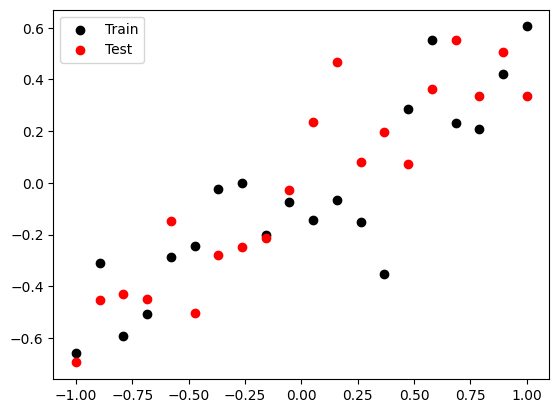

In [6]:
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.legend()
plt.show()

##Regression model


In [7]:
model = Sequential()
model.add(Dense(128,input_dim = 1,activation = 'relu'))
model.add(Dense(128,activation = 'relu'))
model.add(Dense(1,activation = 'linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse'])
history= model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
_, train_mse = model.evaluate(X_train,y_train,verbose=0)
_, test_mse = model.evaluate(X_test,y_test,verbose=0)
print('Train: {}, Test: {}'.format(train_mse,test_mse))

Train: 0.0017405003309249878, Test: 0.06334437429904938


In [10]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


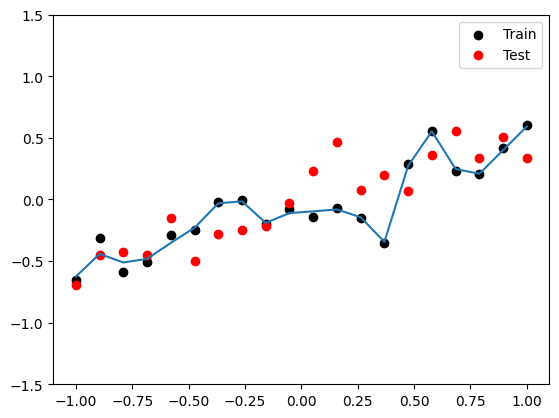

In [11]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

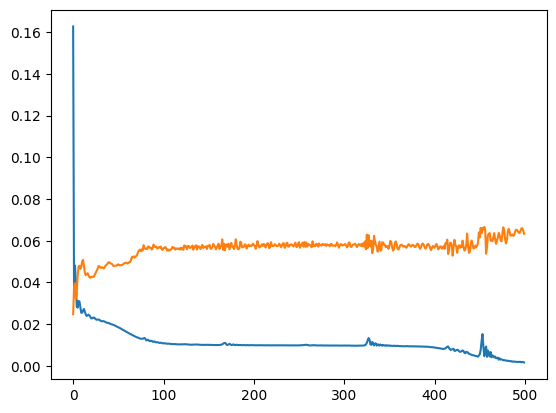

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

##Dropout model

In [20]:
model = Sequential()
model.add(Dense(128,input_dim=1,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss='mse',optimizer=adam,metrics=['mse'])

history = model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
_, train_mse = model.evaluate(X_train,y_train,verbose=0)
_, test_mse = model.evaluate(X_test,y_test,verbose=0)
print('Train: {}, Test: {}'.format(train_mse,test_mse))

Train: 0.019504627212882042, Test: 0.049288537353277206


In [22]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


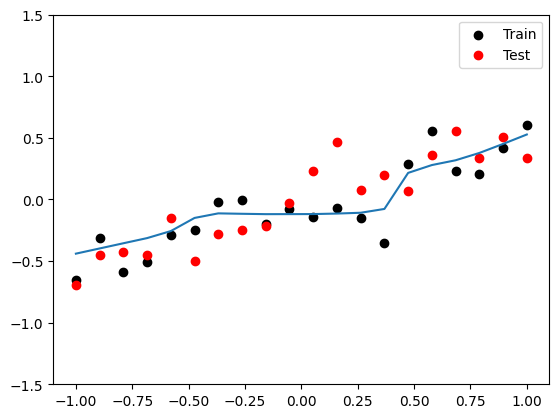

In [23]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='Train')
plt.scatter(X_test,y_test,c='red',label='Test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

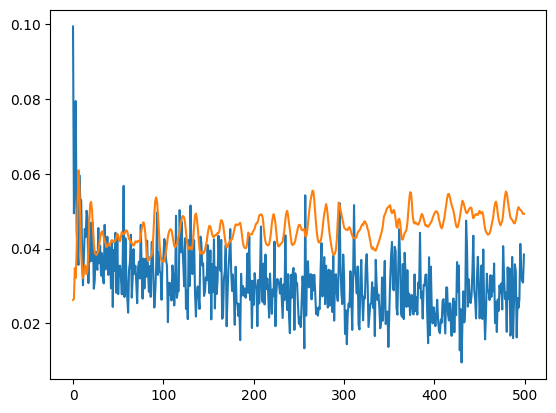

In [24]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])